## 1. Environment Setup & Configuration

In [1]:
import os
import urllib.request
import zipfile
import glob
import math
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from scipy import signal
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve
)
from IPython.display import display, Markdown

# 1. Strict Determinism & Seeding
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

def seed_everything(seed=0):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

SEED = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything(SEED)
print(f"Global seed set to {SEED} on device: {device}")

Global seed set to 0 on device: cuda


## 2. Dataset Acquisition & Preprocessing

In [2]:
# --- Step 1: Download & Extract UCI HAR ---
DATASET_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ZIP_PATH = "har_dataset.zip"
EXTRACT_DIR = "uci_har_data"

if not os.path.exists(EXTRACT_DIR):
    print("Downloading UCI HAR dataset...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    inner_zip = os.path.join(EXTRACT_DIR, "UCI HAR Dataset.zip")
    if os.path.exists(inner_zip):
        with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
    print("UCI HAR Ready!")
else:
    print("UCI HAR already downloaded.")

# --- Step 2: Load & Resample UCI HAR ---
BASE_PATH = os.path.join(EXTRACT_DIR, "UCI HAR Dataset")
SIGNAL_NAMES = [
    "total_acc_x", "total_acc_y", "total_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z"
]

def load_har_signals(mode="train"):
    signals_list = []
    for sig in SIGNAL_NAMES:
        file_path = os.path.join(BASE_PATH, mode, "Inertial Signals", f"{sig}_{mode}.txt")
        data = np.loadtxt(file_path)
        signals_list.append(data)
    return np.transpose(np.array(signals_list), (1, 2, 0))

def preprocess_and_window(X_raw, orig_fs=50, target_fs=100, window_sec=2.0):
    num_samples, orig_len, num_channels = X_raw.shape
    resampled_len = int(orig_len * (target_fs / orig_fs))
    target_samples = int(window_sec * target_fs)

    X_resampled = np.zeros((num_samples, resampled_len, num_channels))
    for i in range(num_samples):
        for c in range(num_channels):
            X_resampled[i, :, c] = signal.resample(X_raw[i, :, c], resampled_len)

    center_idx = resampled_len // 2
    half_window = target_samples // 2
    return X_resampled[:, center_idx - half_window : center_idx + half_window, :]

X_train_100hz = preprocess_and_window(load_har_signals("train"))
X_test_100hz = preprocess_and_window(load_har_signals("test"))

# --- Step 2.5: Robust SisFall Download ---
import gdown

SISFALL_ZIP = "SisFall.zip"
SISFALL_DIR = "./SisFall_dataset"

if not os.path.exists(SISFALL_DIR):
    print("Downloading SisFall dataset from Google Drive mirror...")
    file_id = '1-E-TLd5_J-DDWZXkuYL-moMpoezlMn4Z'
    gdown.download(id=file_id, output=SISFALL_ZIP, quiet=False, fuzzy=True)

    print("Extracting SisFall dataset...")
    try:
        with zipfile.ZipFile(SISFALL_ZIP, 'r') as zip_ref:
            zip_ref.extractall(SISFALL_DIR)
        print("SisFall dataset downloaded and extracted successfully!")
    except zipfile.BadZipFile:
        print("Error: Downloaded file is invalid. Check Google Drive permissions or gdown version.")
else:
    print("SisFall dataset already exists locally. Skipping download.")

# --- Step 3: Anomaly Parsing ---
ACCEL_RANGE_G = 16
ACCEL_RES_BITS = 13
GYRO_RANGE_DPS = 2000
GYRO_RES_BITS = 16

ACCEL_SCALE_G = (2 * ACCEL_RANGE_G) / (2 ** ACCEL_RES_BITS)
GYRO_SCALE_RAD = (2 * GYRO_RANGE_DPS) / (2 ** GYRO_RES_BITS) * (np.pi / 180)

def load_sisfall_anomalies(sisfall_dir, target_fs=100, window_sec=2.0):
    """
    Parses SisFall fall files and keeps the single peak-impact window per
    file, at the sensor's real recorded intensity. (A prior version of
    this function scaled 50% of files down to 0.75x/0.50x amplitude to
    probe Isolation Forest's reliance on raw amplitude -- removed here so
    the main results reflect real SisFall data; that's a fair question to
    ask, but belongs in its own clearly-labeled ablation, not silently
    inside the primary reported numbers.)
    """
    orig_fs = 200
    target_samples = int(window_sec * target_fs)

    fall_files = glob.glob(os.path.join(sisfall_dir, '**', 'F*.txt'), recursive=True)
    if not fall_files:
        raise FileNotFoundError(f"No SisFall anomaly files found in {sisfall_dir}.")

    fall_files = sorted(fall_files)
    windows = []
    n_files_used = 0
    print(f"Processing {len(fall_files)} SisFall files...")

    error_printed = False
    for idx, f in enumerate(fall_files):
        try:
            file_data = []
            with open(f, 'r') as file:
                for line in file:
                    cleaned_line = line.strip().rstrip(';').rstrip(',')
                    if not cleaned_line:
                        continue
                    parts = cleaned_line.split(',')
                    if len(parts) >= 9:
                        try:
                            row_raw = [float(p) for p in parts[:9]]
                            accel = [v * ACCEL_SCALE_G for v in row_raw[0:3]]
                            gyro = [v * GYRO_SCALE_RAD for v in row_raw[3:6]]
                            file_data.append(accel + gyro)
                        except ValueError:
                            continue

            data = np.array(file_data)
            if data.size == 0 or data.shape[1] != 6:
                continue

            resampled_len = int(len(data) * (target_fs / orig_fs))
            data_resampled = signal.resample(data, resampled_len, axis=0)

            num_windows = len(data_resampled) // target_samples
            if num_windows == 0:
                continue

            best_window = None
            best_score = -np.inf
            for i in range(num_windows):
                start = i * target_samples
                end = start + target_samples
                w = data_resampled[start:end, :]
                accel_mag = np.linalg.norm(w[:, 0:3], axis=1)
                peak = accel_mag.max()
                if peak > best_score:
                    best_score = peak
                    best_window = w

            windows.append(best_window)
            n_files_used += 1

        except Exception as e:
            if not error_printed:
                print(f"Error parsing file {f}: {e}")
                error_printed = True
            continue

    windows = np.array(windows)
    print(f"Files successfully parsed       : {n_files_used} / {len(fall_files)}")
    print(f"Total anomaly windows generated : {windows.shape[0]}")
    return windows

X_sisfall_all = load_sisfall_anomalies(SISFALL_DIR)

UCI HAR already downloaded.
SisFall dataset already exists locally. Skipping download.
Processing 1744 SisFall files...
Files successfully parsed       : 1744 / 1744
Total anomaly windows generated : 1744


## 3. Gated Recurrent Unit (GRU) and Transformer Model Architecture

### 3.1: Shared Components & Transformer Architecture

In [3]:
# --- Shared Architecture Components ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0).to(device)

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)].detach()

class ForecastDecoder(nn.Module):
    def __init__(
        self, hidden_size, n_layers, window_size, forecast_horizon,
        conv_channels=32, kernel_size=3, hidden_fc=256, dropout=0.1, n_channels=6
    ):
        super().__init__()
        self.n_layers = n_layers
        self.hidden_size = hidden_size
        self.forecast_horizon = forecast_horizon
        self.n_channels = n_channels

        self.conv1d = nn.Conv1d(
            in_channels=n_layers * hidden_size,
            out_channels=conv_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )
        self.activation = nn.ReLU()
        self.fc = nn.Sequential(
            nn.Linear(conv_channels * window_size, hidden_fc),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_fc, forecast_horizon * n_channels)
        )

    def forward(self, layer_outputs: list):
        batch_size, L, _ = layer_outputs[0].shape
        stacked = torch.stack(layer_outputs, dim=1)
        stacked = stacked.permute(0, 1, 3, 2).reshape(batch_size, self.n_layers * self.hidden_size, L)
        conv_out = self.activation(self.conv1d(stacked))
        conv_out = conv_out.flatten(start_dim=1)
        forecast = self.fc(conv_out)
        forecast = forecast.view(batch_size, self.forecast_horizon, self.n_channels)
        return forecast

# --- Transformer Encoder & Forecaster Architecture ---
class TransformerEncoderLayer(nn.Module):
    def __init__(self, hidden_size, n_heads, hidden_fc, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(hidden_size, n_heads, dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.fc1 = nn.Sequential(
            nn.Linear(hidden_size, hidden_fc),
            nn.ReLU(),
            nn.Linear(hidden_fc, hidden_size)
        )
        self.norm2 = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attn_mask):
        attn_out, _ = self.self_attn(x, x, x, attn_mask=attn_mask, need_weights=False)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.fc1(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

class TransformerEncoderStack(nn.Module):
    def __init__(self, hidden_size, n_heads, hidden_fc, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [TransformerEncoderLayer(hidden_size, n_heads, hidden_fc, dropout) for _ in range(n_layers)]
        )
        self.n_layers = n_layers

    def forward(self, x: torch.Tensor, attn_mask: torch.Tensor = None):
        layer_outputs = []
        for layer in self.layers:
            x = layer(x, attn_mask=attn_mask)
            layer_outputs.append(x)
        return layer_outputs

class TransformerForecaster(nn.Module):
    def __init__(
        self, input_size: int, hidden_size: int, window_size: int = 50,
        forecast_horizon=50, n_heads: int = 8, n_layers: int = 3,
        conv_channels=32, fc_layers=2, kernel_size=3, hidden_fc=256,
        dropout: float = 0.1, use_pos_encoding=False
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.pos_encoding = (
            PositionalEncoding(hidden_size, max_len=window_size)
            if use_pos_encoding else None
        )
        self.encoder = TransformerEncoderStack(hidden_size, n_heads, hidden_fc, n_layers, dropout)
        self.decoder = ForecastDecoder(
            hidden_size, n_layers, window_size, forecast_horizon, conv_channels,
            kernel_size, hidden_fc, dropout, n_channels=input_size
        )

    @staticmethod
    def _generate_causal_mask(size: int, device) -> torch.Tensor:
        return torch.triu(torch.ones(size, size, device=device, dtype=torch.bool), diagonal=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, L, _ = x.shape
        device = x.device
        h = self.input_proj(x)
        if self.pos_encoding is not None:
            h = self.pos_encoding(h)
        causal_mask = self._generate_causal_mask(L, device)
        layer_outputs = self.encoder(h, attn_mask=causal_mask)
        forecast = self.decoder(layer_outputs)
        return forecast

### 3.2: GRU Architecture

In [4]:
# --- GRU Encoder & Forecaster Architecture ---
class GRUEncoderLayer(nn.Module):
    def __init__(self, hidden_size, hidden_fc, dropout):
        super().__init__()
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers=1, batch_first=True)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.fc1 = nn.Sequential(
            nn.Linear(hidden_size, hidden_fc),
            nn.ReLU(),
            nn.Linear(hidden_fc, hidden_size)
        )
        self.norm2 = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        x = self.norm1(x + self.dropout(gru_out))
        ff_out = self.fc1(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

class GRUEncoderStack(nn.Module):
    def __init__(self, hidden_size, hidden_fc, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [GRUEncoderLayer(hidden_size, hidden_fc, dropout) for _ in range(n_layers)]
        )
        self.n_layers = n_layers

    def forward(self, x: torch.Tensor):
        layer_outputs = []
        for layer in self.layers:
            x = layer(x)
            layer_outputs.append(x)
        return layer_outputs

class GRUForecaster(nn.Module):
    def __init__(
        self, input_size: int, hidden_size: int, window_size: int = 50,
        forecast_horizon=50, n_heads: int = 8, n_layers: int = 3,
        conv_channels=32, fc_layers=2, kernel_size=3, hidden_fc=256,
        dropout: float = 0.1, use_pos_encoding=False
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.pos_encoding = (
            PositionalEncoding(hidden_size, max_len=window_size)
            if use_pos_encoding else None
        )
        self.encoder = GRUEncoderStack(hidden_size, hidden_fc, n_layers, dropout)
        self.decoder = ForecastDecoder(
            hidden_size, n_layers, window_size, forecast_horizon, conv_channels,
            kernel_size, hidden_fc, dropout, n_channels=input_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x)
        if self.pos_encoding is not None:
            h = self.pos_encoding(h)
        layer_outputs = self.encoder(h)
        forecast = self.decoder(layer_outputs)
        return forecast

### 3.3: Model Initialization & Verification Script

In [5]:
import torch.optim as optim
import torchinfo

window_size = 200
forecast_horizon = 1
learning_rate = 0.001
BATCH_SIZE = 64 

# --- Select and Initialize Model ---
# To switch models, simply replace TransformerForecaster with GRUForecaster below:
model = TransformerForecaster(
    input_size=6,
    hidden_size=32,
    n_heads=8,             # Unused by GRUForecaster, but safe to leave here
    hidden_fc=32,
    n_layers=3,
    window_size=window_size - forecast_horizon,
    forecast_horizon=forecast_horizon,
    conv_channels=16,
    kernel_size=9,
    dropout=0.1,
    use_pos_encoding=True  # Can set False when testing GRU if preferred
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Created {type(model).__name__}, Using Positional Encoding: {bool(model.pos_encoding)}")

# Display model summary and parameter count
torchinfo.summary(
    model, 
    input_size=(BATCH_SIZE, window_size - forecast_horizon, model.input_proj.in_features), 
    device=device
)

Created TransformerForecaster, Using Positional Encoding: True


Layer (type:depth-idx)                        Output Shape              Param #
TransformerForecaster                         [64, 1, 6]                --
├─Linear: 1-1                                 [64, 199, 32]             224
├─PositionalEncoding: 1-2                     [64, 199, 32]             --
├─TransformerEncoderStack: 1-3                [64, 199, 32]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [64, 199, 32]             6,464
│    │    └─TransformerEncoderLayer: 3-2      [64, 199, 32]             6,464
│    │    └─TransformerEncoderLayer: 3-3      [64, 199, 32]             6,464
├─ForecastDecoder: 1-4                        [64, 1, 6]                --
│    └─Conv1d: 2-2                            [64, 16, 199]             13,840
│    └─ReLU: 2-3                              [64, 16, 199]             --
│    └─Sequential: 2-4                        [64, 6]                   --
│    │

## 4. Anomaly Ratio

In [6]:
# --- Step 5: Test Pool Setup with Configurable Anomaly Ratio ---
seed_everything(SEED)

n_total_train = X_train_100hz.shape[0]
n_val = int(n_total_train * 0.10)
perm = np.random.permutation(n_total_train)
val_idx, fit_idx = perm[:n_val], perm[n_val:]

X_fit_raw = X_train_100hz[fit_idx]
X_val_raw = X_train_100hz[val_idx]

# =====================================================================
# TEST SET CONFIGURATION
# To use an 80% Normal / 20% Anomaly test set (like your presentation),
# change ANOMALY_RATIO to 0.20. For a balanced 50/50 test set, use 0.50.
# =====================================================================
ANOMALY_RATIO = 0.50  # <-- CHANGE TO 0.20 FOR AN 80/20 TEST SPLIT
# =====================================================================

n_normal_full = X_test_100hz.shape[0]
n_anomaly_available = X_sisfall_all.shape[0]

# FIX: the old formula always assumed anomalies were the scarce resource,
# so at low ratios (e.g. 0.20) it demanded more normal data than exists,
# got silently clamped to the full normal pool, but never reduced the
# anomaly count to match -- producing ~37% actual anomaly rate instead of
# the requested 20%. Compute both directions and use whichever is the
# real binding constraint, so ANOMALY_RATIO is hit exactly either way.
ideal_n_anomaly_at_full_normal = int(round(n_normal_full * ANOMALY_RATIO / (1 - ANOMALY_RATIO)))

if ideal_n_anomaly_at_full_normal <= n_anomaly_available:
    # Enough anomalies exist to hit the ratio while keeping the full normal pool.
    n_normal_test = n_normal_full
    n_anomaly_test = ideal_n_anomaly_at_full_normal
else:
    # Not enough anomalies -- use all of them, and take only as much normal
    # data as needed to hit the ratio exactly (this is the path that was
    # already correct at ANOMALY_RATIO = 0.50).
    n_anomaly_test = n_anomaly_available
    n_normal_test = int(round(n_anomaly_available * (1 - ANOMALY_RATIO) / ANOMALY_RATIO))

perm_normal_test = np.random.choice(n_normal_full, min(n_normal_test, n_normal_full), replace=False)
X_test_normal = X_test_100hz[perm_normal_test]

unused_normal_mask = np.ones(n_normal_full, dtype=bool)
unused_normal_mask[perm_normal_test] = False
X_unused_normal = X_test_100hz[unused_normal_mask]

# Recycle unused normal test data into fit pool (zero data waste)
X_fit_raw = np.concatenate([X_fit_raw, X_unused_normal], axis=0)

perm_anomaly_test = np.random.choice(n_anomaly_available, min(n_anomaly_test, n_anomaly_available), replace=False)
X_test_anomaly = X_sisfall_all[perm_anomaly_test]

X_test_combined = np.concatenate([X_test_normal, X_test_anomaly], axis=0)
y_test_labels = np.concatenate([np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))], axis=0)

X_fit_tensor = torch.tensor(X_fit_raw, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_raw, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_combined, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_labels, dtype=torch.float32)

# Z-score normalization strictly calibrated on the fit pool
fit_mean = X_fit_tensor.mean(dim=(0, 1), keepdim=True)
fit_std = X_fit_tensor.std(dim=(0, 1), keepdim=True) + 1e-8

X_fit_tensor = (X_fit_tensor - fit_mean) / fit_std
X_val_tensor = (X_val_tensor - fit_mean) / fit_std
X_test_tensor = (X_test_tensor - fit_mean) / fit_std

BATCH_SIZE = 64
g_train = torch.Generator()
g_train.manual_seed(SEED)

train_loader = DataLoader(
    TensorDataset(X_fit_tensor), batch_size=BATCH_SIZE, shuffle=True, generator=g_train
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor), batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False
)

## 5. Deep Learning Models -> Training

In [7]:
# --- Step 6: Model Training & Evaluation ---
from sklearn.ensemble import IsolationForest

window_size = 200
forecast_horizon = 1
learning_rate = 0.001
epochs = 20

MODEL_CLASSES = {
    "GRU": GRUForecaster,
    "Transformer": TransformerForecaster,
}

COMMON_KWARGS = dict(
    input_size=6,
    hidden_size=32,
    n_heads=8,
    hidden_fc=32,
    n_layers=3,
    window_size=window_size - forecast_horizon,
    forecast_horizon=forecast_horizon,
    conv_channels=16,
    kernel_size=9,
    dropout=0.1,
    use_pos_encoding=True,
)

results = {}
history = {}
roc_data = {}
cms = {}
trained_models = {}

for model_name, model_class in MODEL_CLASSES.items():
    print(f"\n{'=' * 60}\nTraining {model_name}\n{'=' * 60}")
    seed_everything(SEED)
    g_train = torch.Generator()
    g_train.manual_seed(SEED)

    train_loader = DataLoader(
        TensorDataset(X_fit_tensor), batch_size=BATCH_SIZE, shuffle=True, generator=g_train
    )

    model = model_class(**COMMON_KWARGS).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history[model_name] = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for batch in train_loader:
            x_data = batch[0].to(device)
            inputs = x_data[:, :-forecast_horizon, :]
            targets = x_data[:, -forecast_horizon:, :]

            optimizer.zero_grad()
            y_pred = model(inputs)
            loss = criterion(y_pred, targets)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        model.eval()
        val_losses, val_scores = [], []
        with torch.no_grad():
            for batch in val_loader:
                x_data = batch[0].to(device)
                inputs = x_data[:, :-forecast_horizon, :]
                targets = x_data[:, -forecast_horizon:, :]
                preds = model(inputs)
                sample_mse = torch.mean((preds - targets) ** 2, dim=(1, 2)).cpu().numpy()
                val_scores.extend(sample_mse)
                val_losses.append(criterion(preds, targets).item())
        
        val_scores = np.array(val_scores)
        threshold = np.percentile(val_scores, 95)
        val_loss = np.mean(val_losses)
        
        history[model_name]["train_loss"].append(train_loss)
        history[model_name]["val_loss"].append(val_loss)
        print(f"Epoch {epoch:>3}: train MSE = {train_loss:.6f}, val MSE = {val_loss:.6f}")

    trained_models[model_name] = model

    anomaly_scores, ground_truth = [], []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            inputs = x_batch[:, :-forecast_horizon, :]
            targets = x_batch[:, -forecast_horizon:, :]
            preds = model(inputs)
            sample_mse = torch.mean((preds - targets) ** 2, dim=(1, 2)).cpu().numpy()
            anomaly_scores.extend(sample_mse)
            ground_truth.extend(y_batch.numpy())

    anomaly_scores = np.array(anomaly_scores)
    ground_truth = np.array(ground_truth)
    binary_preds = (anomaly_scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(ground_truth, binary_preds).ravel()
    cms[model_name] = confusion_matrix(ground_truth, binary_preds)
    roc_data[model_name] = roc_curve(ground_truth, anomaly_scores)

    results[model_name] = dict(
        precision=precision_score(ground_truth, binary_preds, zero_division=0),
        recall=recall_score(ground_truth, binary_preds, zero_division=0),
        f1=f1_score(ground_truth, binary_preds, zero_division=0),
        roc_auc=roc_auc_score(ground_truth, anomaly_scores),
        far=fp / (fp + tn),
        threshold=threshold,
        tn=tn, fp=fp, fn=fn, tp=tp
    )


Training GRU
Epoch   0: train MSE = 0.373022, val MSE = 0.153485
Epoch   1: train MSE = 0.178343, val MSE = 0.102569
Epoch   2: train MSE = 0.133557, val MSE = 0.071474
Epoch   3: train MSE = 0.112798, val MSE = 0.061288
Epoch   4: train MSE = 0.105586, val MSE = 0.051624
Epoch   5: train MSE = 0.094632, val MSE = 0.050793
Epoch   6: train MSE = 0.090041, val MSE = 0.056545
Epoch   7: train MSE = 0.089018, val MSE = 0.041158
Epoch   8: train MSE = 0.082274, val MSE = 0.040103
Epoch   9: train MSE = 0.079869, val MSE = 0.037352
Epoch  10: train MSE = 0.079769, val MSE = 0.034071
Epoch  11: train MSE = 0.074542, val MSE = 0.029297
Epoch  12: train MSE = 0.076985, val MSE = 0.032492
Epoch  13: train MSE = 0.072135, val MSE = 0.029186
Epoch  14: train MSE = 0.072393, val MSE = 0.031293
Epoch  15: train MSE = 0.071639, val MSE = 0.032117
Epoch  16: train MSE = 0.072299, val MSE = 0.028396
Epoch  17: train MSE = 0.072899, val MSE = 0.023875
Epoch  18: train MSE = 0.069140, val MSE = 0.02415

## 6. Isolation Forest Training

In [8]:
# --- Train Classical Baseline: Isolation Forest ---
print(f"\n{'=' * 60}\nTraining Isolation Forest\n{'=' * 60}")
seed_everything(SEED)

X_fit_flat = X_fit_tensor.numpy().reshape(X_fit_tensor.shape[0], -1)
X_val_flat = X_val_tensor.numpy().reshape(X_val_tensor.shape[0], -1)
X_test_flat = X_test_tensor.numpy().reshape(X_test_tensor.shape[0], -1)

iso_forest = IsolationForest(contamination=0.05, random_state=SEED, n_jobs=-1)
iso_forest.fit(X_fit_flat)

val_iso_scores = -iso_forest.decision_function(X_val_flat)
iso_threshold = np.percentile(val_iso_scores, 95)

test_iso_scores = -iso_forest.decision_function(X_test_flat)
iso_binary_preds = (test_iso_scores >= iso_threshold).astype(int)

tn_if, fp_if, fn_if, tp_if = confusion_matrix(y_test_labels, iso_binary_preds).ravel()
cms["Isolation Forest"] = confusion_matrix(y_test_labels, iso_binary_preds)
roc_data["Isolation Forest"] = roc_curve(y_test_labels, test_iso_scores)

results["Isolation Forest"] = dict(
    precision=precision_score(y_test_labels, iso_binary_preds, zero_division=0),
    recall=recall_score(y_test_labels, iso_binary_preds, zero_division=0),
    f1=f1_score(y_test_labels, iso_binary_preds, zero_division=0),
    roc_auc=roc_auc_score(y_test_labels, test_iso_scores),
    far=fp_if / (fp_if + tn_if),
    threshold=iso_threshold,
    tn=tn_if, fp=fp_if, fn=fn_if, tp=tp_if
)


Training Isolation Forest


## 6. Model Evaluation & Performance Visualization

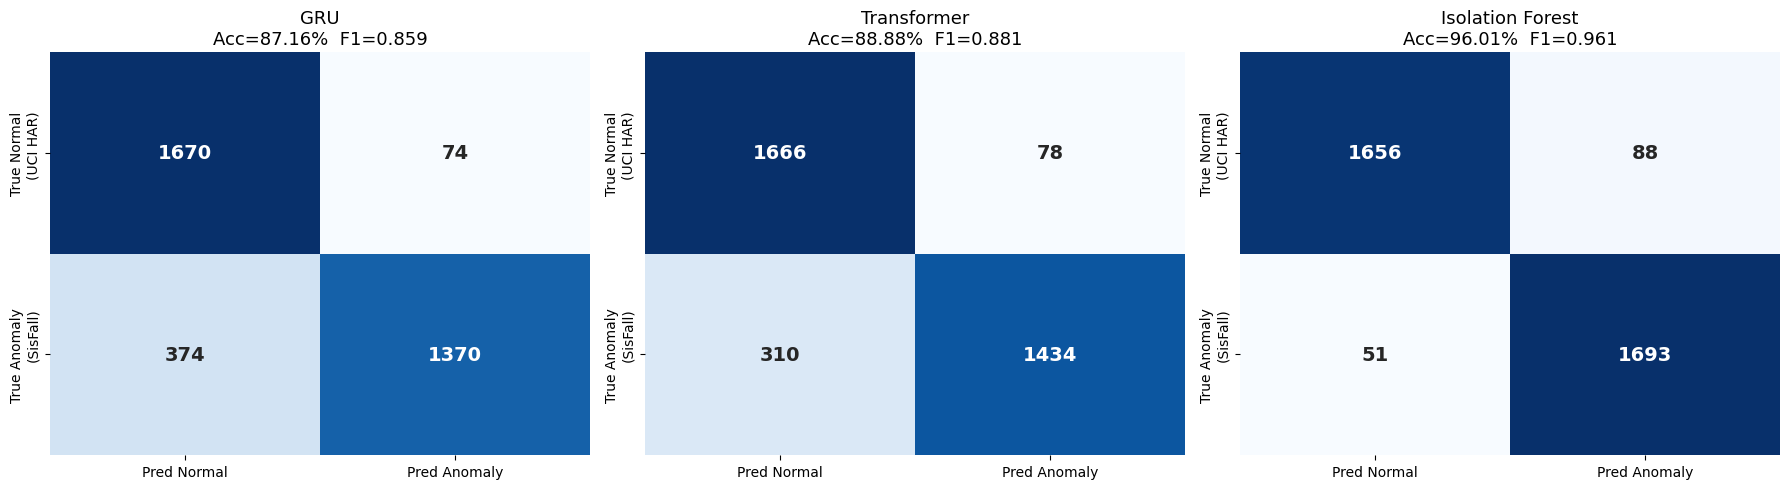

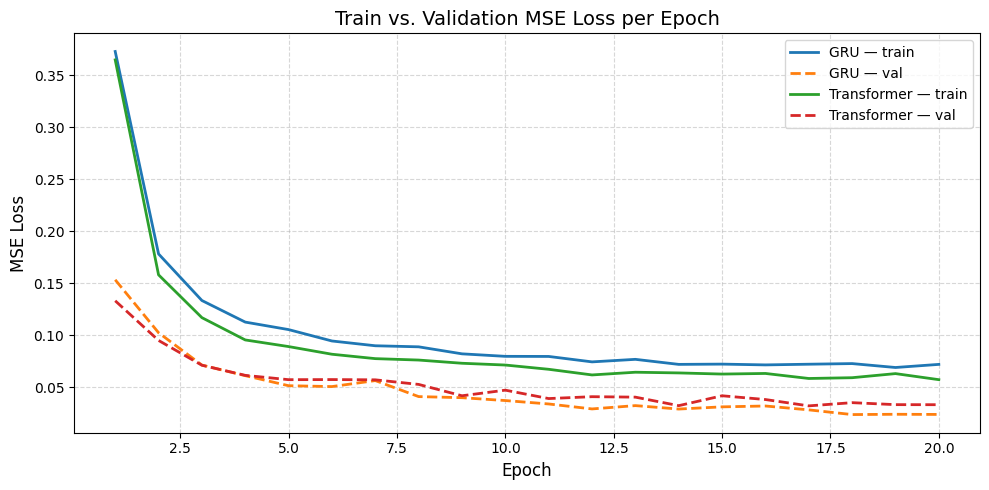

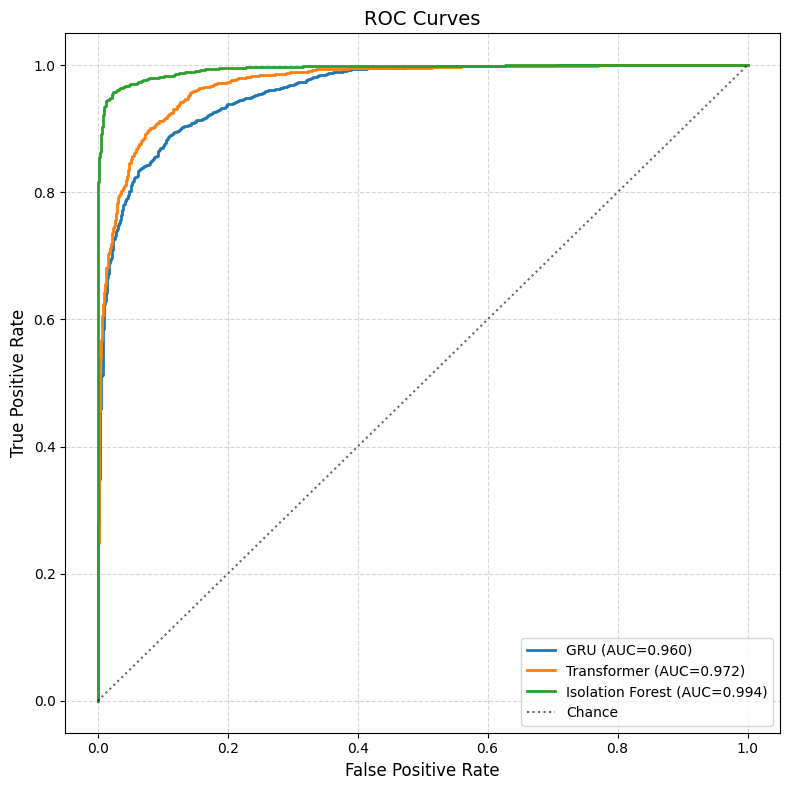

Comparison at ANOMALY_RATIO = 50% test-set anomaly rate
(re-run data split and training cells, then this cell to update table)



,Precision,Recall,F1,ROC-AUC,FAR (%),Threshold,TN,FP,FN,TP,Complexity
Model,,,,,,,,,,,
GRU,0.9488,0.7856,0.8595,0.9599,4.24,0.097383,1670,74,374,1370,"141,910 params"
Transformer,0.9484,0.8222,0.8808,0.9718,4.47,0.125286,1666,78,310,1434,"135,574 params"
Isolation Forest,0.9506,0.9708,0.9606,0.9939,5.05,-0.001919,1656,88,51,1693,100 trees



Markdown table (copy-paste ready):

| Model | Precision | Recall | F1 | ROC-AUC | FAR | Complexity |
|---|---|---|---|---|---|---|
| GRU | 0.9488 | 0.7856 | 0.8595 | 0.9599 | 4.24% | 141,910 params |
| Transformer | 0.9484 | 0.8222 | 0.8808 | 0.9718 | 4.47% | 135,574 params |
| Isolation Forest | 0.9506 | 0.9708 | 0.9606 | 0.9939 | 5.05% | 100 trees |


| Model | Precision | Recall | F1 | ROC-AUC | FAR | Complexity |
|---|---|---|---|---|---|---|
| GRU | 0.9488 | 0.7856 | 0.8595 | 0.9599 | 4.24% | 141,910 params |
| Transformer | 0.9484 | 0.8222 | 0.8808 | 0.9718 | 4.47% | 135,574 params |
| Isolation Forest | 0.9506 | 0.9708 | 0.9606 | 0.9939 | 5.05% | 100 trees |

In [9]:
# =====================================================================
# STEP 7: VISUALIZATION SUITE (CONFUSION MATRICES, LOSS & ROC CURVES)
# =====================================================================

# 1. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, cm) in enumerate(cms.items()):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
        annot_kws={"size": 14, "weight": "bold"},
        xticklabels=['Pred Normal', 'Pred Anomaly'],
        yticklabels=['True Normal\n(UCI HAR)', 'True Anomaly\n(SisFall)']
    )
    acc = np.trace(cm) / np.sum(cm)
    f1 = results[name]["f1"]
    axes[i].set_title(f"{name}\nAcc={acc*100:.2f}%  F1={f1:.3f}", fontsize=13)
plt.tight_layout()
plt.show()

# 2. Train vs Validation MSE Loss Curves
plt.figure(figsize=(10, 5))
for name, hist in history.items():
    plt.plot(range(1, epochs + 1), hist["train_loss"], label=f"{name} — train", lw=2)
    plt.plot(range(1, epochs + 1), hist["val_loss"], '--', label=f"{name} — val", lw=2)
plt.title("Train vs. Validation MSE Loss per Epoch", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 3. ROC Curves
plt.figure(figsize=(8, 8))
for name, (fpr, tpr, _) in roc_data.items():
    auc_val = results[name]["roc_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", lw=2)
plt.plot([0, 1], [0, 1], 'k:', label="Chance", alpha=0.6)
plt.title("ROC Curves", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# =====================================================================
# STEP 8: VISUAL COMPARISON TABLE & COPY-PASTE READY MARKDOWN
# =====================================================================

MODEL_ORDER = ["GRU", "Transformer", "Isolation Forest"]

comparison_rows = []
for name in MODEL_ORDER:
    r_raw = results.get(name, {})
    
    # Normalize dictionary keys to lowercase to avoid case-sensitivity issues
    r = {str(k).lower(): v for k, v in r_raw.items()}
    
    # Dynamically compute complexity if missing or set to N/A
    complexity = r.get("complexity", None)
    if not complexity or complexity == "N/A":
        if "trained_models" in globals() and name in trained_models:
            num_params = sum(p.numel() for p in trained_models[name].parameters() if p.requires_grad)
            complexity = f"{num_params:,} params"
        elif name == "Isolation Forest" and "iso_forest" in globals():
            n_trees = getattr(iso_forest, "n_estimators", 100)
            complexity = f"{n_trees} trees"
        else:
            complexity = "N/A"

    # Safely extract metrics with default fallbacks
    precision = r.get("precision", 0)
    recall = r.get("recall", 0)
    f1 = r.get("f1", r.get("f1_score", 0))
    roc_auc = r.get("roc_auc", 0)
    far = r.get("far", 0)
    threshold = r.get("threshold", 0)
    
    tn = r.get("tn", 0)
    fp = r.get("fp", 0)
    fn = r.get("fn", 0)
    tp = r.get("tp", 0)

    comparison_rows.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "FAR (%)": round(far * 100, 2),
        "Threshold": round(threshold, 6),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Complexity": complexity,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")

print(f"Comparison at ANOMALY_RATIO = {ANOMALY_RATIO:.0%} test-set anomaly rate")
print(f"(re-run data split and training cells, then this cell to update table)\n")
display(comparison_df)

# Markdown-ready version for reports
md_lines = ["| Model | Precision | Recall | F1 | ROC-AUC | FAR | Complexity |",
            "|---|---|---|---|---|---|---|"]
for row in comparison_rows:
    md_lines.append(
        f"| {row['Model']} | {row['Precision']:.4f} | {row['Recall']:.4f} | "
        f"{row['F1']:.4f} | {row['ROC-AUC']:.4f} | {row['FAR (%)']:.2f}% | {row['Complexity']} |"
    )

print("\nMarkdown table (copy-paste ready):\n")
print("\n".join(md_lines))
display(Markdown("\n".join(md_lines)))

## 50% Anomalies:

| Model | Precision | Recall | F1 | ROC-AUC | FAR | Complexity |
|---|---|---|---|---|---|---|
| GRU | 0.9488 | 0.7856 | 0.8595 | 0.9599 | 4.24% | 141,910 params |
| Transformer | 0.9484 | 0.8222 | 0.8808 | 0.9718 | 4.47% | 135,574 params |
| Isolation Forest | 0.9506 | 0.9708 | 0.9606 | 0.9939 | 5.05% | 100 trees |

## 20% anomalies:

| Model | Precision | Recall | F1 | ROC-AUC | FAR | Complexity |
|---|---|---|---|---|---|---|
| GRU | 0.7909 | 0.8005 | 0.7957 | 0.9631 | 5.29% | 141,910 params |
| Transformer | 0.7967 | 0.8562 | 0.8254 | 0.9725 | 5.46% | 135,574 params |
| Isolation Forest | 0.8215 | 0.9742 | 0.8914 | 0.9937 | 5.29% | 100 trees |